# Lab 2 Part 2 - Breast Cancer Preprocessing (Phase A)
En la geometria del sistema de coordenadas, cada muestra vive en un espacio de caracteristicas $\mathbf{x} \in \mathbb{R}^d$. Para preparar la normalizacion Z-score, mapeamos estados cualitativos a una variedad discreta numerica:
$$\phi: \{B, M\} \to \{0,1\}, \quad \phi(B)=0, \ hi(M)=1$$
Este mapeo preserva la semantica diagnostica y permite integrar la etiqueta en pipelines numericos reproducibles.

**Aclaración Metodológica:** Este laboratorio fue desarrollado utilizando la metodología de **Vibe Coding** con asistencia de Inteligencia Artificial (GitHub Copilot / GPT-5.3-Codex), priorizando el diseño de la arquitectura (Engine/Runner) y el rigor matemático de la *Física de Datos* sobre la escritura manual de sintaxis.

> 1. Leer los datos desde una página web.

In [1]:
from pathlib import Path
import io
import json

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from ucimlrepo import fetch_ucirepo

from src.kinematics import FeatureEngineeringEngine

breast_cancer_wisconsin_diagnostic = fetch_ucirepo(id=17)
X = breast_cancer_wisconsin_diagnostic.data.features
y = breast_cancer_wisconsin_diagnostic.data.targets

engine = FeatureEngineeringEngine(X, y)
system_df = engine.build_system_dataframe(target_column_name="Diagnosis")

print("--- Respuestas al Laboratorio 2 Parte 2 ---")
print("1. Datos leídos desde página web usando ucimlrepo (id=17).")
print(f"   Registros: {system_df.shape[0]}, Columnas: {system_df.shape[1]}")
print(system_df.head())

--- Respuestas al Laboratorio 2 Parte 2 ---
1. Datos leídos desde página web usando ucimlrepo (id=17).
   Registros: 569, Columnas: 31
   radius1  texture1  perimeter1   area1  smoothness1  compactness1  \
0    17.99     10.38      122.80  1001.0      0.11840       0.27760   
1    20.57     17.77      132.90  1326.0      0.08474       0.07864   
2    19.69     21.25      130.00  1203.0      0.10960       0.15990   
3    11.42     20.38       77.58   386.1      0.14250       0.28390   
4    20.29     14.34      135.10  1297.0      0.10030       0.13280   

   concavity1  concave_points1  symmetry1  fractal_dimension1  ...  texture3  \
0      0.3001          0.14710     0.2419             0.07871  ...     17.33   
1      0.0869          0.07017     0.1812             0.05667  ...     23.41   
2      0.1974          0.12790     0.2069             0.05999  ...     25.53   
3      0.2414          0.10520     0.2597             0.09744  ...     26.50   
4      0.1980          0.10430     0.1

> 2. Renombrar las columnas en formato PascalCase.

In [2]:
system_df = engine.normalize_columns_pascal_case()

print("2. Columnas renombradas en formato PascalCase.")
print("   Primeras 10 columnas:")
for col in system_df.columns.tolist()[:10]:
    print(f"   - {col}")

2. Columnas renombradas en formato PascalCase.
   Primeras 10 columnas:
   - Radius1
   - Texture1
   - Perimeter1
   - Area1
   - Smoothness1
   - Compactness1
   - Concavity1
   - ConcavePoints1
   - Symmetry1
   - FractalDimension1


> 3. Utilizar los métodos head(), tail(), describe() e info() para obtener información sobre el DataFrame.

In [3]:
print("3. Resumen del DataFrame con head(), tail(), describe() e info().")
print("\n3.1 head():")
display(system_df.head())

print("\n3.2 tail():")
display(system_df.tail())

print("\n3.3 describe(include='all'):")
display(system_df.describe(include="all"))

print("\n3.4 info():")
buffer = io.StringIO()
system_df.info(buf=buffer)
print(buffer.getvalue())

3. Resumen del DataFrame con head(), tail(), describe() e info().

3.1 head():


,Radius1,Texture1,Perimeter1,Area1,Smoothness1,Compactness1,Concavity1,ConcavePoints1,Symmetry1,FractalDimension1,...,Texture3,Perimeter3,Area3,Smoothness3,Compactness3,Concavity3,ConcavePoints3,Symmetry3,FractalDimension3,Diagnosis
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,M
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,M
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,M
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,M
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,M



3.2 tail():


,Radius1,Texture1,Perimeter1,Area1,Smoothness1,Compactness1,Concavity1,ConcavePoints1,Symmetry1,FractalDimension1,...,Texture3,Perimeter3,Area3,Smoothness3,Compactness3,Concavity3,ConcavePoints3,Symmetry3,FractalDimension3,Diagnosis
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,M
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,M
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,M
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,M
568,7.76,24.54,47.92,181.0,0.05263,0.04362,0.00000,0.00000,0.1587,0.05884,...,30.37,59.16,268.6,0.08996,0.06444,0.0000,0.0000,0.2871,0.07039,B



3.3 describe(include='all'):


,Radius1,Texture1,Perimeter1,Area1,Smoothness1,Compactness1,Concavity1,ConcavePoints1,Symmetry1,FractalDimension1,...,Texture3,Perimeter3,Area3,Smoothness3,Compactness3,Concavity3,ConcavePoints3,Symmetry3,FractalDimension3,Diagnosis
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,B
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,357
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,NaN
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,NaN
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,NaN
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,NaN
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,NaN
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,NaN



3.4 info():
<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Radius1            569 non-null    float64
 1   Texture1           569 non-null    float64
 2   Perimeter1         569 non-null    float64
 3   Area1              569 non-null    float64
 4   Smoothness1        569 non-null    float64
 5   Compactness1       569 non-null    float64
 6   Concavity1         569 non-null    float64
 7   ConcavePoints1     569 non-null    float64
 8   Symmetry1          569 non-null    float64
 9   FractalDimension1  569 non-null    float64
 10  Radius2            569 non-null    float64
 11  Texture2           569 non-null    float64
 12  Perimeter2         569 non-null    float64
 13  Area2              569 non-null    float64
 14  Smoothness2        569 non-null    float64
 15  Compactness2       569 non-null    float64
 16  Concavity2         569 n

> 4. Contabilizar la cantidad de valores nulos (null o NaN) en el DataFrame. Si se encuentran valores nulos, ¿qué estrategia propondrías para reemplazarlos?

In [4]:
null_profile = engine.get_null_profile()
total_nulls = null_profile["TotalNullCount"]

print("4. Conteo de valores null/NaN en el sistema:")
print(f"   Total null/NaN: {total_nulls}")
for col, count in null_profile["NullCountByColumn"].items():
    print(f"   - {col}: {count}")

if total_nulls > 0:
    print("   Estrategia propuesta: imputación por mediana (numéricas) y moda (categóricas).")
else:
    print("   No hay nulos; no se requiere imputación en esta fase.")

4. Conteo de valores null/NaN en el sistema:
   Total null/NaN: 0
   - Radius1: 0
   - Texture1: 0
   - Perimeter1: 0
   - Area1: 0
   - Smoothness1: 0
   - Compactness1: 0
   - Concavity1: 0
   - ConcavePoints1: 0
   - Symmetry1: 0
   - FractalDimension1: 0
   - Radius2: 0
   - Texture2: 0
   - Perimeter2: 0
   - Area2: 0
   - Smoothness2: 0
   - Compactness2: 0
   - Concavity2: 0
   - ConcavePoints2: 0
   - Symmetry2: 0
   - FractalDimension2: 0
   - Radius3: 0
   - Texture3: 0
   - Perimeter3: 0
   - Area3: 0
   - Smoothness3: 0
   - Compactness3: 0
   - Concavity3: 0
   - ConcavePoints3: 0
   - Symmetry3: 0
   - FractalDimension3: 0
   - Diagnosis: 0
   No hay nulos; no se requiere imputación en esta fase.


> 5. Identificar los valores únicos en la columna target que representan las etiquetas B y M.

In [5]:
target_column = "Diagnosis"
unique_labels = sorted(system_df[target_column].dropna().unique().tolist())

print("5. Valores únicos en la columna target (Diagnosis):")
for i, label in enumerate(unique_labels, start=1):
    print(f"   {i}. {label}")
unique_labels

5. Valores únicos en la columna target (Diagnosis):
   1. B
   2. M


['B', 'M']

> 6. Realizar un conteo de los casos etiquetados como B y M utilizando la librería seaborn y el método countplot().

6. Conteo de casos B y M con seaborn countplot().
   B (Benigno): 357
   M (Maligno): 212


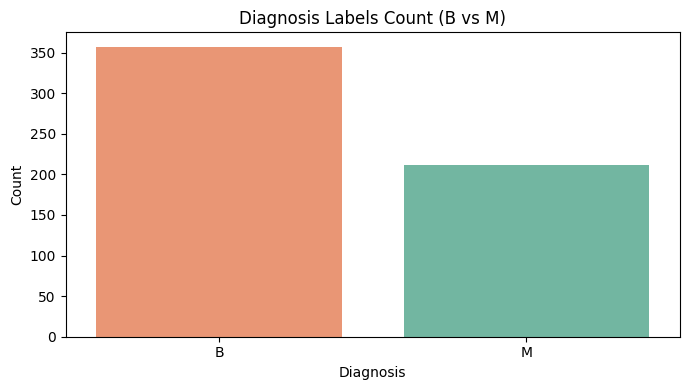

In [6]:
label_counts = system_df[target_column].value_counts()

print("6. Conteo de casos B y M con seaborn countplot().")
print(f"   B (Benigno): {int(label_counts.get('B', 0))}")
print(f"   M (Maligno): {int(label_counts.get('M', 0))}")

plt.figure(figsize=(7, 4))
sns.countplot(data=system_df, x=target_column, order=["B", "M"], hue=target_column, palette="Set2", legend=False)
plt.title("Diagnosis Labels Count (B vs M)")
plt.xlabel("Diagnosis")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

> 7. Agregar una nueva columna llamada DiagnosisNumeric donde se asigna el valor 0 a la etiqueta B (Benigno) y el valor 1 a la etiqueta M (Maligno).

In [7]:
system_df = engine.map_diagnosis_numeric(source_column=target_column, target_column="DiagnosisNumeric")

print("7. Se creó la columna DiagnosisNumeric con mapeo B->0 y M->1.")
print(system_df[[target_column, "DiagnosisNumeric"]].head())
print("   Valores únicos en DiagnosisNumeric:", sorted(system_df["DiagnosisNumeric"].dropna().unique().tolist()))

artifact = {
    "NullProfile": null_profile,
    "TargetDistribution": engine.get_target_distribution(target_column=target_column)
}
artifact_dir_candidates = [Path("artifacts"), Path("../artifacts")]
artifact_dir = next((p for p in artifact_dir_candidates if p.exists()), artifact_dir_candidates[0])
artifact_path = artifact_dir / "02_cancer_profile.json"
artifact_path.parent.mkdir(parents=True, exist_ok=True)
with open(artifact_path, "w", encoding="utf-8") as f:
    json.dump(artifact, f, indent=2, ensure_ascii=False)

print(f"   Artifact generado: {artifact_path}")
artifact_path

7. Se creó la columna DiagnosisNumeric con mapeo B->0 y M->1.
  Diagnosis  DiagnosisNumeric
0         M                 1
1         M                 1
2         M                 1
3         M                 1
4         M                 1
   Valores únicos en DiagnosisNumeric: [0, 1]
   Artifact generado: ../artifacts/02_cancer_profile.json


PosixPath('../artifacts/02_cancer_profile.json')

## Symmetry and Scaling
En el espacio de fases, la normalización Z-score es una transformación lineal que centra el sistema en el origen y escala las fluctuaciones a varianza unitaria:
$$z = \frac{x-\mu}{\sigma}$$
Así, cada coordenada queda en una escala comparable, preservando simetrías relativas entre variables.

> 8. Normalizar cada columna respecto a su media y desviación estándar utilizando la fórmula: (x - mean(x)) / std(x)

In [8]:
feature_columns = [
    col for col in system_df.select_dtypes(include=["number"]).columns
    if col != "DiagnosisNumeric"
]

system_df = engine.zscore_normalize_features(exclude_columns=["DiagnosisNumeric"])

z_means = system_df[feature_columns].mean(axis=0)
z_stds = system_df[feature_columns].std(axis=0, ddof=0)
verification_df = pd.DataFrame({"Mu": z_means, "Sigma": z_stds})

print("8. Normalización Z-score aplicada: (x - mean(x)) / std(x)")
print("   Verificación (primeras 10 columnas):")
display(verification_df.head(10))
print("   Max |mu|:", float(verification_df["Mu"].abs().max()))
print("   Max |sigma-1|:", float((verification_df["Sigma"] - 1.0).abs().max()))

8. Normalización Z-score aplicada: (x - mean(x)) / std(x)
   Verificación (primeras 10 columnas):


,Mu,Sigma
Radius1,-1.373633e-16,1.0
Texture1,6.868164e-17,1.0
Perimeter1,-1.248757e-16,1.0
Area1,-2.185325e-16,1.0
Smoothness1,-8.366672e-16,1.0
Compactness1,1.873136e-16,1.0
Concavity1,4.995028e-17,1.0
ConcavePoints1,-4.995028e-17,1.0
Symmetry1,1.748260e-16,1.0
FractalDimension1,4.745277e-16,1.0


   Max |mu|: 8.366671932500301e-16
   Max |sigma-1|: 2.220446049250313e-16


> 9. Agrupar características similares y calcular su promedio. Para las siguientes características: ['RadiusMean', 'TextureMean', 'PerimeterMean', 'AreaMean', 'SmoothnessMean', 'CompactnessMean', 'ConcavityMean', 'ConcavePointsMean', 'SymmetryMean', 'FractalDimensionMean'] Usa expresiones regulares para identificar patrones comunes, como radius1, radius2, radius3, etc., y calcular los promedios.

In [9]:
system_df, grouped_sources = engine.add_grouped_feature_averages_regex()

expected_grouped_cols = [
    "RadiusMean",
    "TextureMean",
    "PerimeterMean",
    "AreaMean",
    "SmoothnessMean",
    "CompactnessMean",
    "ConcavityMean",
    "ConcavePointsMean",
    "SymmetryMean",
    "FractalDimensionMean"
]
grouped_cols = [col for col in expected_grouped_cols if col in system_df.columns]

grouped_feature_means = {
    col: float(system_df[col].mean())
    for col in grouped_cols
}

grouped_artifact = {
    "GroupedFeatureColumns": grouped_cols,
    "GroupedFeatureMeans": grouped_feature_means,
    "GroupedFeatureSources": grouped_sources
}

artifact_dir_candidates = [Path("artifacts"), Path("../artifacts")]
artifact_dir = next((p for p in artifact_dir_candidates if p.exists()), artifact_dir_candidates[0])
grouped_artifact_path = artifact_dir / "02_cancer_grouped_features.json"
grouped_artifact_path.parent.mkdir(parents=True, exist_ok=True)

with open(grouped_artifact_path, "w", encoding="utf-8") as f:
    json.dump(grouped_artifact, f, indent=2, ensure_ascii=False)

print("9. Características agrupadas por regex y promediadas correctamente.")
for col in grouped_cols:
    print(f"   - {col}: media={grouped_feature_means[col]:.6f}")
print(f"   Artifact generado: {grouped_artifact_path}")
pd.DataFrame({"GroupedColumn": grouped_cols, "Mean": [grouped_feature_means[c] for c in grouped_cols]})

9. Características agrupadas por regex y promediadas correctamente.
   - RadiusMean: media=-0.000000
   - TextureMean: media=0.000000
   - PerimeterMean: media=-0.000000
   - AreaMean: media=-0.000000
   - SmoothnessMean: media=-0.000000
   - CompactnessMean: media=0.000000
   - ConcavityMean: media=0.000000
   - ConcavePointsMean: media=0.000000
   - SymmetryMean: media=0.000000
   - FractalDimensionMean: media=-0.000000
   Artifact generado: ../artifacts/02_cancer_grouped_features.json


,GroupedColumn,Mean
0,RadiusMean,-2.497514e-16
1,TextureMean,0.000000e+00
2,PerimeterMean,-2.122887e-16
3,AreaMean,-1.123881e-16
4,SmoothnessMean,-4.120898e-16
5,CompactnessMean,1.248757e-17
6,ConcavityMean,9.990056e-17
7,ConcavePointsMean,6.243785e-17
8,SymmetryMean,1.748260e-16
9,FractalDimensionMean,-2.497514e-17


## Phase Space Separation
En dinámica estadística, los outliers pueden interpretarse como fluctuaciones de alta energía que perturban la estabilidad del modelo en el espacio de fases.
Si una coordenada excede significativamente la escala típica, su energía efectiva domina el ajuste y sesga fronteras de clasificación.

Para una variable normalizada $z$, consideramos eventos extremos cuando:
$$|z| > 3$$
Estos estados deben inspeccionarse y, cuando procede, removerse para estabilizar la evolución del sistema.

> 10. Crear un gráfico donde se muestre el histograma de la columna RadiusMean separado por las etiquetas B y M, utilizando colores diferentes (naranja y azul, respectivamente) para cada diagnóstico.

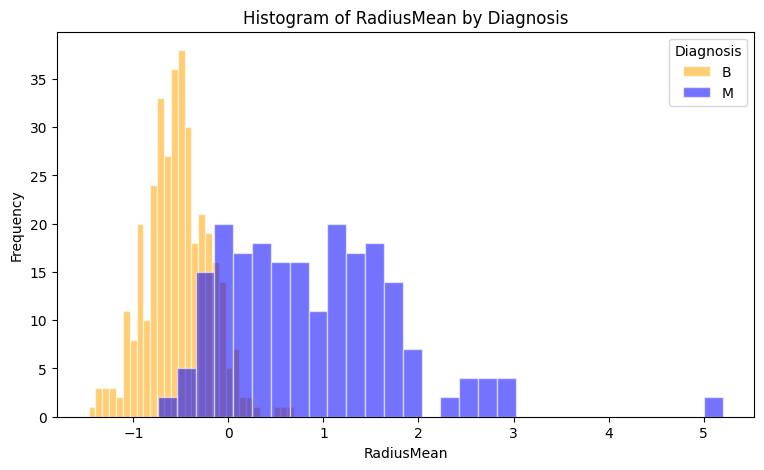

10. Histograma de RadiusMean separado por diagnóstico (B naranja, M azul) generado.
   Ruta: ../artifacts/hist_RadiusMean_Diagnosis.png


'../artifacts/hist_RadiusMean_Diagnosis.png'

In [10]:
from src.visuals import (
    plot_overlapping_hist_by_label,
    plot_multifeature_violin,
    plot_correlation_heatmap,
)

if "RadiusMean" not in system_df.columns:
    system_df, _ = engine.add_grouped_feature_averages_regex()

hist_path = plot_overlapping_hist_by_label(
    system_df,
    value_col="RadiusMean",
    label_col="Diagnosis",
    filename="hist_RadiusMean_Diagnosis.png",
    bins=30,
)

print("10. Histograma de RadiusMean separado por diagnóstico (B naranja, M azul) generado.")
print(f"   Ruta: {hist_path}")
hist_path

> 11. Generar gráficos de violín para múltiples características.

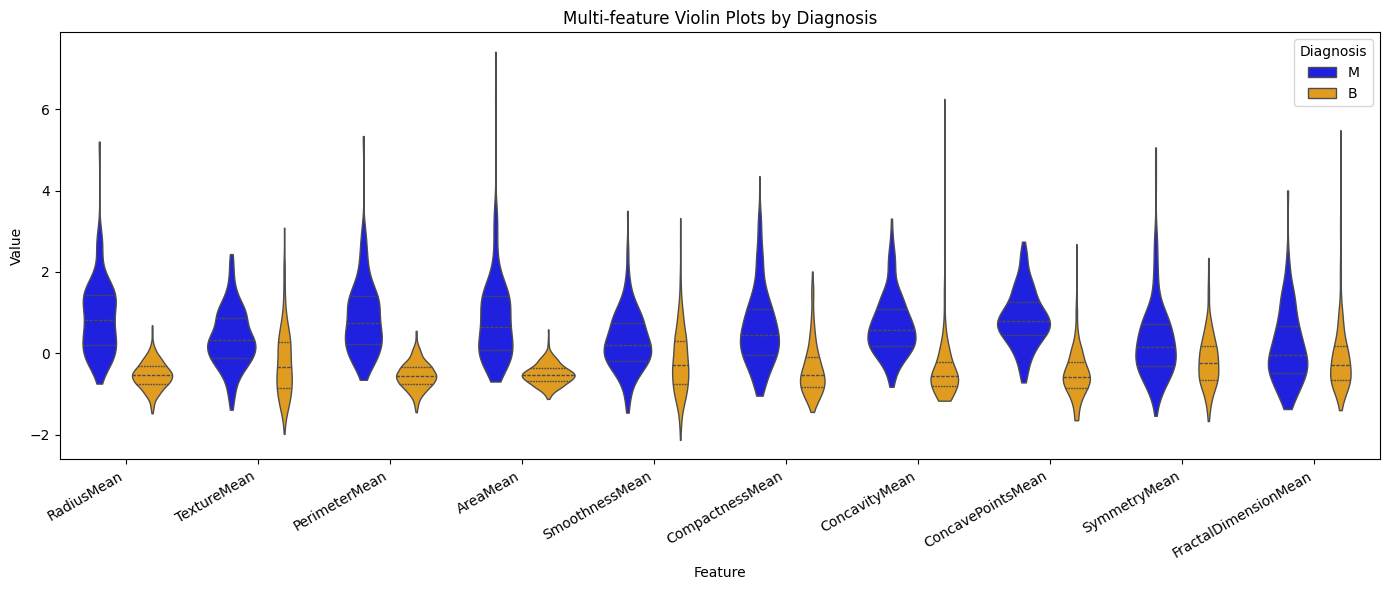

11. Gráficos de violín multicaracterística generados.
   Número de características: 10
   Ruta: ../artifacts/violin_grouped_features_diagnosis.png


'../artifacts/violin_grouped_features_diagnosis.png'

In [11]:
violin_features = [
    "RadiusMean",
    "TextureMean",
    "PerimeterMean",
    "AreaMean",
    "SmoothnessMean",
    "CompactnessMean",
    "ConcavityMean",
    "ConcavePointsMean",
    "SymmetryMean",
    "FractalDimensionMean",
]

violin_path = plot_multifeature_violin(
    system_df,
    feature_columns=violin_features,
    label_col="Diagnosis",
    filename="violin_grouped_features_diagnosis.png",
)

print("11. Gráficos de violín multicaracterística generados.")
print(f"   Número de características: {len(violin_features)}")
print(f"   Ruta: {violin_path}")
violin_path

> 12. Determinar y eliminar los valores atípicos (outliers) en la columna RadiusMean.

In [ ]:
iqr_outliers = engine.detect_outliers_iqr("RadiusMean")
z_outliers = engine.detect_outliers_zscore("RadiusMean", threshold=3.0)
combined_outliers = sorted(set(iqr_outliers).union(z_outliers))

pre_remove_n = int(systObtenga información del data frame.em_df.shape[0])
system_df = engine.remove_outliers(combined_outliers)
post_remove_n = int(system_df.shape[0])
outliers_removed_count = pre_remove_n - post_remove_n

print("12. Detección y remoción de outliers en RadiusMean (IQR y Z-score).")
print(f"   Outliers IQR: {len(iqr_outliers)}")
print(f"   Outliers Z-score: {len(z_outliers)}")
print(f"   Outliers combinados removidos: {len(combined_outliers)}")
print(f"   Filas antes: {pre_remove_n}")
print(f"   Filas después: {post_remove_n}")

12. Detección y remoción de outliers en RadiusMean (IQR y Z-score).
   Outliers IQR: 22
   Outliers Z-score: 6
   Outliers combinados removidos: 22
   Filas antes: 569
   Filas después: 547


> 13. Encontrar la matrix de correlación, emplear el metodo corr(), dentro de seaborn buscar el metodo heatmap() para realizar un grafico de la matrix de correlación.

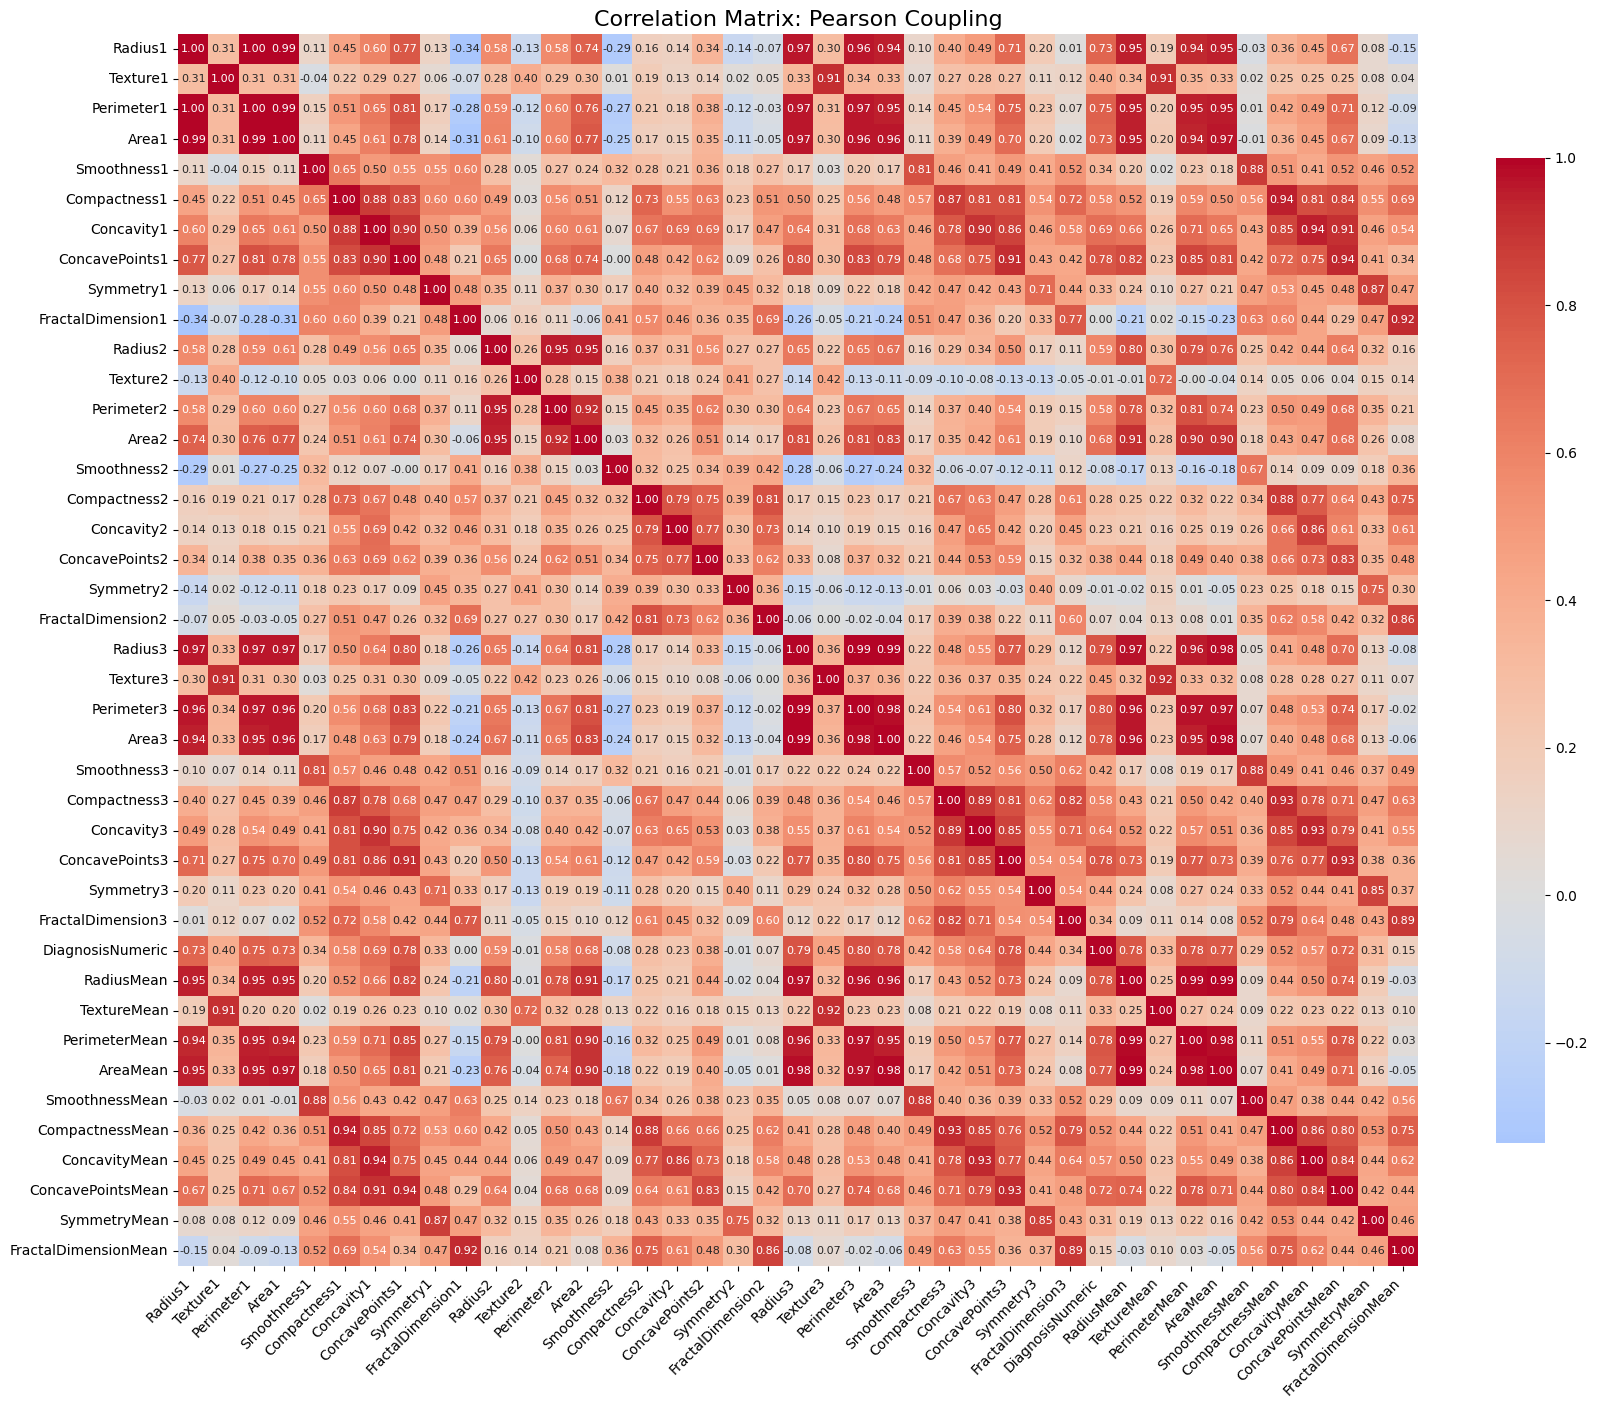

13. Matriz de correlación (corr) y heatmap de seaborn generados.
   Top 5 correlaciones más fuertes:
   1. Perimeter1 vs Radius1: corr=0.997308
   2. Radius3 vs Perimeter3: corr=0.992302
   3. Area1 vs Radius1: corr=0.992220
   4. Perimeter1 vs Area1: corr=0.990330
   5. Area3 vs Radius3: corr=0.989820
   Heatmap: ../artifacts/heatmap_pearson.png
   Reporte final: ../artifacts/02_cancer_final_report.json


,FeatureA,FeatureB,Correlation,AbsCorrelation
82,Perimeter1,Radius1,0.997308,0.997308
842,Radius3,Perimeter3,0.992302,0.992302
123,Area1,Radius1,0.992220,0.992220
85,Perimeter1,Area1,0.990330,0.990330
963,Area3,Radius3,0.989820,0.989820


In [13]:
numeric_df = system_df.select_dtypes(include=["number"])
corr_matrix = numeric_df.corr()

heatmap_path = plot_correlation_heatmap(system_df, method="pearson")

corr_pairs = corr_matrix.where(~np.eye(corr_matrix.shape[0], dtype=bool)).stack().reset_index()
corr_pairs.columns = ["FeatureA", "FeatureB", "Correlation"]
corr_pairs["AbsCorrelation"] = corr_pairs["Correlation"].abs()

corr_pairs["PairKey"] = corr_pairs.apply(
    lambda row: "__".join(sorted([row["FeatureA"], row["FeatureB"]])),
    axis=1,
)
strongest_top5 = (
    corr_pairs.sort_values("AbsCorrelation", ascending=False)
    .drop_duplicates(subset=["PairKey"])
    .head(5)
    .drop(columns=["PairKey"])
)

final_report = {
    "OutliersRemoved": int(outliers_removed_count),
    "OutlierDetail": {
        "IqrOutliers": int(len(iqr_outliers)),
        "ZscoreOutliers": int(len(z_outliers)),
        "CombinedOutliers": int(len(combined_outliers)),
    },
    "Top5StrongestCorrelations": [
        {
            "FeatureA": str(row.FeatureA),
            "FeatureB": str(row.FeatureB),
            "Correlation": float(row.Correlation),
            "AbsCorrelation": float(row.AbsCorrelation),
        }
        for row in strongest_top5.itertuples(index=False)
    ],
}

artifact_dir_candidates = [Path("artifacts"), Path("../artifacts")]
artifact_dir = next((p for p in artifact_dir_candidates if p.exists()), artifact_dir_candidates[0])
final_report_path = artifact_dir / "02_cancer_final_report.json"
with open(final_report_path, "w", encoding="utf-8") as f:
    json.dump(final_report, f, indent=2, ensure_ascii=False)

print("13. Matriz de correlación (corr) y heatmap de seaborn generados.")
print("   Top 5 correlaciones más fuertes:")
for i, row in enumerate(strongest_top5.itertuples(index=False), start=1):
    print(f"   {i}. {row.FeatureA} vs {row.FeatureB}: corr={row.Correlation:.6f}")
print(f"   Heatmap: {heatmap_path}")
print(f"   Reporte final: {final_report_path}")
display(strongest_top5)

> 14. ¿Que otro tipo de gráficos pueden ser realizados para entender mejor los datos?
"> 
"> Además del histograma, violín y heatmap, se pueden usar: pairplot (relaciones bivariadas), boxplot/boxenplot (dispersión robusta), KDE por clase (densidades), scatter con reducción PCA/UMAP (separabilidad en baja dimensión), y clustermap (estructura de bloques de correlación).

In [14]:
print("14. Otros gráficos recomendados para entender mejor los datos:")
print("   1) pairplot para relaciones bivariadas por clase.")
print("   2) boxplot y boxenplot para comparar dispersión robusta.")
print("   3) KDE por clase para contrastar densidades.")
print("   4) PCA/UMAP con scatter para visualizar separabilidad.")
print("   5) clustermap para detectar bloques de correlación.")

14. Otros gráficos recomendados para entender mejor los datos:
   1) pairplot para relaciones bivariadas por clase.
   2) boxplot y boxenplot para comparar dispersión robusta.
   3) KDE por clase para contrastar densidades.
   4) PCA/UMAP con scatter para visualizar separabilidad.
   5) clustermap para detectar bloques de correlación.
